In [76]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label = ""):
        self.data = data
        self._prev = _children
        self._op = _op
        self.label = label
        self.grad =  0
        self._backward = lambda:None


    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out
    

    def __radd__(self, other):
        return self + other
        

    def __mul__(self,other):
        other = other if  isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self,other):
        return self * other
    
    def __sub__(self,other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)), "only supporting int/float powers for now "
        out = Value(self.data**other,(self,),f"**{other}")

        def _backward():
            self.grad = other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out

    def __iter__(self):
        for child in self._prev:
            yield  child

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward

        return out


    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp")
        def _backward():
            self.grad += out.data  * out.grad
        out._backward = _backward
        return out


a = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"
l

Value(data=-8.0)

In [77]:
a = Value(2.0)
b = Value(3.0)
a,b

(Value(data=2.0), Value(data=3.0))

In [78]:
a.__mul__(b)

Value(data=6.0)

In [79]:
c._prev

()

In [80]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

In [81]:
trace(c)

({Value(data=10)}, set())

In [82]:
from graphviz import Digraph

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a reactangular ('recored') node for it 
        dot.node(name=uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it 
            dot.node(name = uid + n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op )
    return dot

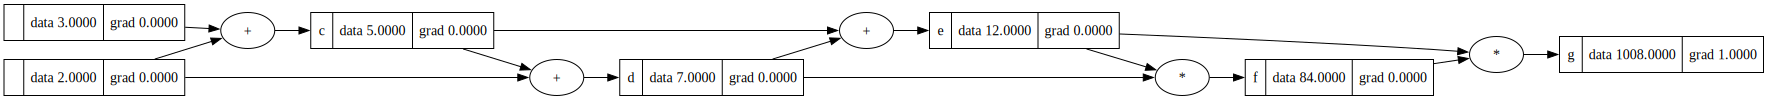

In [83]:
c = a+b; c.label = "c"
d = c+a; d.label = "d"
e = d+c; e.label = "e"
f = e*d; f.label = "f"
g = f*e; g.label = "g"
g.grad = 1.0
draw_dot(g)

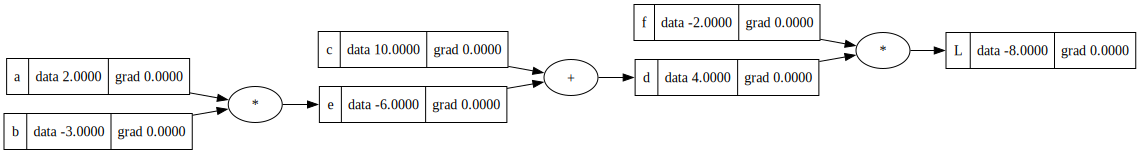

In [93]:
a = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"


draw_dot(l)

In [ ]:
l.backward()
draw_dot(l)